# Credit Card Approval Prediction Using ML

### Introduction

This dataset pertains to Credit Card Approval Prediction, a classification task in the field of financial services. The goal is to predict whether a credit card application will be approved or rejected based on the applicant's attributes. The dataset consists of various features such as income, employment status, credit history, and other personal financial factors.

In this project, we will first perform data cleaning to address any missing values and inconsistencies. Following that, I will apply data balancing techniques to handle any class imbalances. Multiple machine learning algorithms will be trained on the preprocessed data to evaluate their performance. These models will then be fine-tuned to achieve the best possible results.

Once the model is optimized, I plan to build a web application that will provide real-time credit card approval predictions, allowing users to submit their details and receive an immediate decision on their application.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import  warnings 
warnings.filterwarnings('ignore')

In [2]:
# Load application data
app_df = pd.read_csv("application_record.csv")

In [3]:
app_df.shape

(438557, 18)

In [4]:
app_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [5]:
app_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [6]:
app_df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [7]:
app_df.isna().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [8]:
app_df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)

In [9]:
# Converting ages and days of employment into understandable numbers
app_df['AGE'] = (-app_df['DAYS_BIRTH']) // 365

In [10]:
app_df['YEARS_EMPLOYED'] = app_df['DAYS_EMPLOYED'].apply(lambda x: -1 if x == 365243 else (-x) // 365)

In [11]:
app_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,Unknown,1.0,62,-1
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0,43,8
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0,22,1
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,Unknown,2.0,59,-1


In [12]:
# Load credit record data
credit_df = pd.read_csv("credit_record.csv")

In [13]:
credit_df.shape

(1048575, 3)

In [14]:
credit_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [15]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [16]:
credit_df.describe()

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


In [17]:
credit_df.isna().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [18]:
# Preparing the target column (label)
def define_target(status_list):
    return 0 if any(s in ['2','3','4','5'] for s in status_list) else 1

target_df = credit_df.groupby('ID')['STATUS'].apply(list).reset_index()
target_df['TARGET'] = target_df['STATUS'].apply(define_target)
target_df.drop('STATUS', axis=1, inplace=True)

In [19]:
target_df

,ID,TARGET
0,5001711,1
1,5001712,1
2,5001713,1
3,5001714,1
4,5001715,1
...,...,...
45980,5150482,1
45981,5150483,1
45982,5150484,1
45983,5150485,1


In [20]:
# Final data merge
merged_df = app_df.merge(target_df, on='ID', how='inner')

In [21]:
print(f"Final shape: {merged_df.shape}")
merged_df.head()

Final shape: (36457, 21)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,32,12,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,32,12,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,-1134,1,0,0,0,Security staff,2.0,58,3,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,52,8,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,52,8,1


In [22]:
merged_df.isna().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
AGE                    0
YEARS_EMPLOYED         0
TARGET                 0
dtype: int64

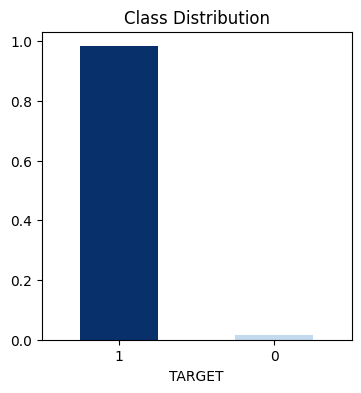

In [23]:
# Data balance check
plt.figure(figsize=(4, 4))
plt.tick_params(axis='x', rotation=0)

merged_df['TARGET'].value_counts(normalize=True).plot(
    kind='bar',
    title='Class Distribution',
    color=['#08306b', '#c3daee']
)
plt.tick_params(axis='x', rotation=0)

Convert categorical columns to numeric values using ColumnTransformer with OneHotEncoder

In [24]:
# Importing necessary libraries
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline

Separating Features from the Target

In [25]:
X = merged_df[['CODE_GENDER', 'FLAG_OWN_CAR', 'AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED', 'CNT_FAM_MEMBERS', 'NAME_EDUCATION_TYPE']]

y = merged_df['TARGET']

In [26]:
X.head()

,CODE_GENDER,FLAG_OWN_CAR,AMT_INCOME_TOTAL,AGE,YEARS_EMPLOYED,CNT_FAM_MEMBERS,NAME_EDUCATION_TYPE
0,M,Y,427500.0,32,12,2.0,Higher education
1,M,Y,427500.0,32,12,2.0,Higher education
2,M,Y,112500.0,58,3,2.0,Secondary / secondary special
3,F,N,270000.0,52,8,1.0,Secondary / secondary special
4,F,N,270000.0,52,8,1.0,Secondary / secondary special


In [27]:
# Define numeric and categorical columns
numerical_cols = ['AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED', 'CNT_FAM_MEMBERS']
categorical_cols = ['CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_EDUCATION_TYPE']

In [28]:
# Splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [29]:
# Remove outliers from training data only
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

In [30]:
# Apply the function to X_train and update y_train based on the indexes
X_train_clean = remove_outliers_iqr(X_train.copy(), numerical_cols)
y_train_clean = y_train.loc[X_train_clean.index]

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first'), categorical_cols)
])


In [32]:
import os
os.makedirs("modelspre", exist_ok=True)

In [33]:
# مثال:
preprocessor.fit(X_train)

import joblib
joblib.dump(preprocessor, 'modelspre/preprocessor.pkl')

['modelspre/preprocessor.pkl']

In [34]:
feature_names = preprocessor.get_feature_names_out()

# تأكد وجود المجلد model
import os
os.makedirs('modelfea', exist_ok=True)

# حفظ أسماء الميزات الصحيحة
joblib.dump(feature_names, 'modelfea/features.pkl')

['modelfea/features.pkl']

In [35]:
# Transform training and test data
X_train_transformed = preprocessor.fit_transform(X_train_clean)
X_test_transformed = preprocessor.transform(X_test)

Data balancing using SMOTE

In [36]:
# Using SMOTE for data balancing
smote = SMOTE(random_state=42)

In [37]:
# Applying SMOTE on transferred data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train_clean)

Check the balance after balancing

In [38]:
print(f"Before resampling:\n{y_train_clean.value_counts()}")

Before resampling:
TARGET
1    22382
0      397
Name: count, dtype: int64


In [39]:
print(f"After resampling:\n{y_train_resampled.value_counts()}")

After resampling:
TARGET
1    22382
0    22382
Name: count, dtype: int64


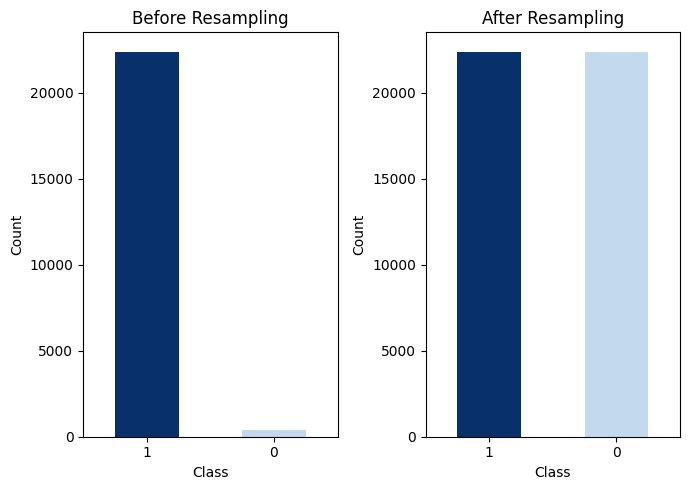

In [40]:
# Data before and after resampling
before_resampling = y_train_clean.value_counts()
after_resampling = y_train_resampled.value_counts()

# Plot to compare before and after resampling
plt.figure(figsize=(7, 5))

# Plot data before resampling
plt.subplot(1, 2, 1)
before_resampling.plot(kind='bar', color=['#08306b', '#c3daee'])
plt.title('Before Resampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tick_params(axis='x', rotation=0)

# Plot data after resampling
plt.subplot(1, 2, 2)
after_resampling.plot(kind='bar', color=['#08306b', '#c3daee'])
plt.title('After Resampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [41]:
# Merge balanced data into a unified DataFrame
df = pd.DataFrame(X_train_resampled.toarray() if hasattr(X_train_resampled, "toarray") else X_train_resampled)

# Rename columns using the column names generated by the preprocessor
# Obtain column names from each Transformer
num_features = preprocessor.named_transformers_['num'].get_feature_names_out(numerical_cols)
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
df.columns = np.concatenate([num_features, cat_features])

# Add target column
df['TARGET'] = y_train_resampled.values

In [42]:
df

,AMT_INCOME_TOTAL,AGE,YEARS_EMPLOYED,CNT_FAM_MEMBERS,CODE_GENDER_M,FLAG_OWN_CAR_Y,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,TARGET
0,-0.532061,-0.512656,0.157422,-0.196418,0.000000,0.000000,0.0,0.0,0.0,1.0,1
1,2.002905,-1.277867,-0.696776,-1.387000,1.000000,1.000000,1.0,0.0,0.0,0.0,1
2,2.002905,0.507625,0.798072,-1.387000,0.000000,1.000000,0.0,0.0,0.0,1.0,1
3,0.101680,-0.597680,1.225171,-0.196418,0.000000,0.000000,0.0,0.0,0.0,1.0,1
4,1.052293,-0.682703,0.157422,0.994164,1.000000,1.000000,0.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
44759,1.801365,-0.698021,1.807721,-0.629752,0.363968,0.363968,0.0,0.0,0.0,1.0,0
44760,-0.806024,1.160354,-1.123876,-1.387000,0.000000,0.000000,0.0,0.0,0.0,1.0,0
44761,0.418551,1.017765,1.225171,-0.196418,0.000000,0.000000,0.0,0.0,0.0,1.0,0
44762,1.305789,-1.107820,0.370972,0.994164,0.055116,1.000000,1.0,0.0,0.0,0.0,0


In [43]:
df.to_csv('cleaned_balanced_data.csv', index=False)

In [44]:
df.to_excel('cleaned_balanced_data.xlsx', index=False)

In [45]:
# Value counts for target (adjust if different name)
print("\nTarget Distribution:\n", df.iloc[:, -1].value_counts())


Target Distribution:
 TARGET
1    22382
0    22382
Name: count, dtype: int64


# Data Preparation

In [46]:
X.head()

,CODE_GENDER,FLAG_OWN_CAR,AMT_INCOME_TOTAL,AGE,YEARS_EMPLOYED,CNT_FAM_MEMBERS,NAME_EDUCATION_TYPE
0,M,Y,427500.0,32,12,2.0,Higher education
1,M,Y,427500.0,32,12,2.0,Higher education
2,M,Y,112500.0,58,3,2.0,Secondary / secondary special
3,F,N,270000.0,52,8,1.0,Secondary / secondary special
4,F,N,270000.0,52,8,1.0,Secondary / secondary special


In [47]:
X = df.iloc[:, :-1]  # Features
y = df.iloc[:, -1]   # Target

In [48]:
X.head()

,AMT_INCOME_TOTAL,AGE,YEARS_EMPLOYED,CNT_FAM_MEMBERS,CODE_GENDER_M,FLAG_OWN_CAR_Y,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special
0,-0.532061,-0.512656,0.157422,-0.196418,0.0,0.0,0.0,0.0,0.0,1.0
1,2.002905,-1.277867,-0.696776,-1.387000,1.0,1.0,1.0,0.0,0.0,0.0
2,2.002905,0.507625,0.798072,-1.387000,0.0,1.0,0.0,0.0,0.0,1.0
3,0.101680,-0.597680,1.225171,-0.196418,0.0,0.0,0.0,0.0,0.0,1.0
4,1.052293,-0.682703,0.157422,0.994164,1.0,1.0,0.0,0.0,0.0,1.0


In [49]:
# Encode categorical variables if any
X = pd.get_dummies(X, drop_first=True)

In [50]:
X_train.head()

,CODE_GENDER,FLAG_OWN_CAR,AMT_INCOME_TOTAL,AGE,YEARS_EMPLOYED,CNT_FAM_MEMBERS,NAME_EDUCATION_TYPE
30988,F,N,135000.0,37,5,2.0,Secondary / secondary special
34340,M,Y,315000.0,28,1,1.0,Higher education
1387,F,Y,315000.0,49,8,1.0,Secondary / secondary special
35729,F,N,180000.0,36,10,2.0,Secondary / secondary special
12367,M,Y,247500.0,35,5,3.0,Secondary / secondary special


In [51]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()
X_train['NAME_EDUCATION_TYPE']= label_encoder.fit_transform(X_train['NAME_EDUCATION_TYPE'])
X_train['CODE_GENDER']= label_encoder.fit_transform(X_train['CODE_GENDER'])
X_train['FLAG_OWN_CAR']= label_encoder.fit_transform(X_train['FLAG_OWN_CAR'])

In [52]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()
X_test['NAME_EDUCATION_TYPE']= label_encoder.fit_transform(X_test['NAME_EDUCATION_TYPE'])
X_test['CODE_GENDER']= label_encoder.fit_transform(X_test['CODE_GENDER'])
X_test['FLAG_OWN_CAR']= label_encoder.fit_transform(X_test['FLAG_OWN_CAR'])


In [53]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
import os
os.makedirs("modelza", exist_ok=True)

In [55]:
import joblib

import joblib
print("الأعمدة التي سيتم حفظها: ", X_train.columns.tolist())


joblib.dump(X_train.columns.tolist(), 'modelza/features.pkl')


الأعمدة التي سيتم حفظها:  ['AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED', 'CNT_FAM_MEMBERS', 'CODE_GENDER_M', 'FLAG_OWN_CAR_Y', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special']


['modelza/features.pkl']

In [56]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models Dictionary

2. Random Forest

In [86]:
# Train the model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [87]:
# Print classification report
print("===== Random Forest =====")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

===== Random Forest =====

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4479
           1       0.98      0.99      0.98      4474

    accuracy                           0.98      8953
   macro avg       0.98      0.98      0.98      8953
weighted avg       0.98      0.98      0.98      8953



Confusion Matrix:


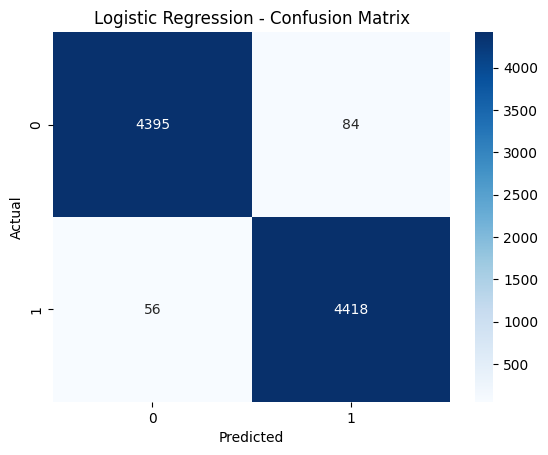

In [88]:

# Confusion Matrix
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

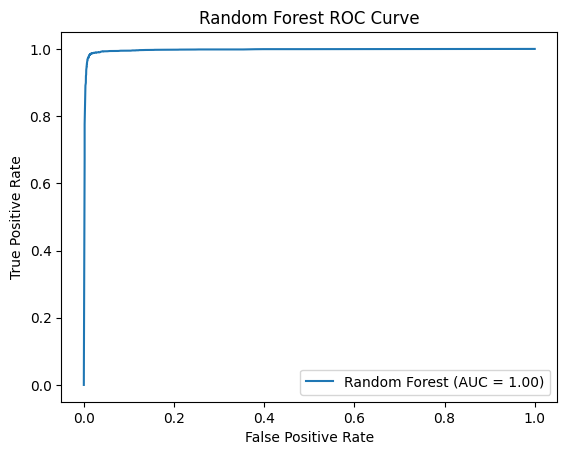

In [89]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.2f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.show()

4. K-Nearest Neighbors (KNN

In [61]:
# Train the model
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

In [62]:
# Print classification report
print("===== K-Nearest Neighbors (KNN) =====")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

===== K-Nearest Neighbors (KNN) =====

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4479
           1       0.96      0.94      0.95      4474

    accuracy                           0.95      8953
   macro avg       0.95      0.95      0.95      8953
weighted avg       0.95      0.95      0.95      8953



Confusion Matrix:


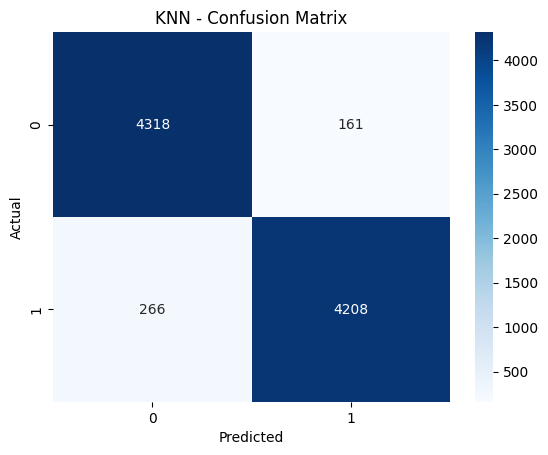

In [63]:
# Confusion Matrix
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

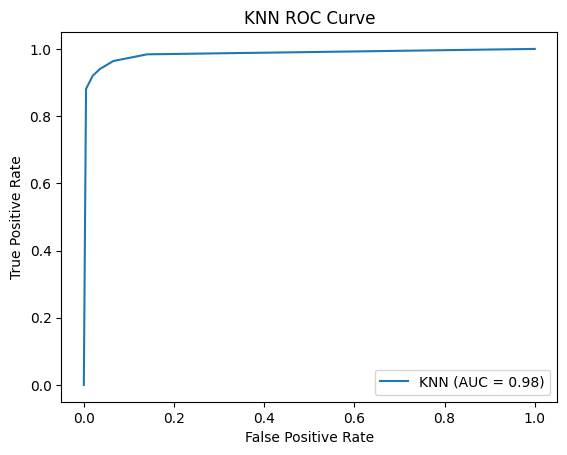

In [64]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"KNN (AUC = {roc_auc:.2f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [65]:
import os
os.makedirs("models", exist_ok=True)

In [66]:
import os
os.makedirs("modelsss", exist_ok=True)

In [67]:
import joblib

In [68]:
joblib.dump(knn, "modelsss/knn.pkl")

['modelsss/knn.pkl']

In [69]:
joblib.dump(preprocessor, "modelsss/preprocessor.pkl")

['modelsss/preprocessor.pkl']

In [70]:
joblib.dump(knn, "modelsss/knn.pkl")

['modelsss/knn.pkl']

In [71]:
import pandas as pd

# إدخال بيانات المستخدم
user_input = pd.DataFrame([{
    'CODE_GENDER': 0,             # 0 = Male, 1 = Female
    'NAME_EDUCATION_TYPE': 2,     # ترميز التعليم
    'FLAG_OWN_CAR': 1,            # 0 = لا، 1 = نعم
    'AMT_INCOME_TOTAL': 120000,   # الدخل السنوي
    'AGE': 30,                    # العمر
    'YEARS_EMPLOYED': 5,          # سنوات العمل
    'CNT_FAM_MEMBERS': 3          # عدد أفراد العائلة
}])



In [72]:
# إعادة ترميز البيانات بنفس طريقة التدريب
user_input_encoded = pd.get_dummies(user_input)

# إعادة ترتيب الأعمدة لتطابق الأعمدة الأصلية المستخدمة أثناء التدريب
# هذا يعتمد على أعمدة X_train بعد OneHotEncoding
expected_columns = np.concatenate([num_features, cat_features])
  # إذا كان X_train ما زال موجود
user_input_encoded = user_input_encoded.reindex(columns=expected_columns, fill_value=0)


In [73]:
user_input_scaled = scaler.transform(user_input_encoded)


In [74]:
user_input = pd.DataFrame([{
    'CODE_GENDER': 'M',                   # 'M' or 'F'
    'NAME_EDUCATION_TYPE': 'Lower secondary',  # النص كما في الأصل
    'FLAG_OWN_CAR': 'N',                 # 'Y' or 'N'
    'AMT_INCOME_TOTAL': 18000,
    'AGE': 19,
    'YEARS_EMPLOYED': 0,
    'CNT_FAM_MEMBERS': 6
}])


In [75]:
# تطبيق المعالجة بنفس preprocessor
user_input_transformed = preprocessor.transform(user_input)

# تحويل إلى DataFrame مع نفس الأعمدة الأصلية
import numpy as np
user_input_df = pd.DataFrame(user_input_transformed, columns=np.concatenate([num_features, cat_features]))


In [76]:
user_input_scaled = scaler.transform(user_input_df)
prediction = knn.predict(user_input_scaled)

if prediction[0] == 1:
    print("✅ النتيجة: تم قبول الطلب.")
else:
    print("❌ النتيجة: تم رفض الطلب.")


❌ النتيجة: تم رفض الطلب.


In [77]:
user_input = pd.DataFrame([{
    'CODE_GENDER': 'M',                   # 'M' or 'F'
    'NAME_EDUCATION_TYPE': 'Higher education',  # النص كما في الأصل
    'FLAG_OWN_CAR': 'Y',                 # 'Y' or 'N'
    'AMT_INCOME_TOTAL': 120000,
    'AGE': 30,
    'YEARS_EMPLOYED': 5,
    'CNT_FAM_MEMBERS': 3
}])


In [78]:
# تطبيق المعالجة بنفس preprocessor
user_input_transformed = preprocessor.transform(user_input)

# تحويل إلى DataFrame مع نفس الأعمدة الأصلية
import numpy as np
user_input_df = pd.DataFrame(user_input_transformed, columns=np.concatenate([num_features, cat_features]))


In [79]:
user_input_scaled = scaler.transform(user_input_df)
prediction = knn.predict(user_input_scaled)

if prediction[0] == 1:
    print("✅ النتيجة: تم قبول الطلب.")
else:
    print("❌ النتيجة: تم رفض الطلب.")


✅ النتيجة: تم قبول الطلب.


In [80]:
user_input = pd.DataFrame([{
    'CODE_GENDER': 'M',                   # 'M' or 'F'
    'NAME_EDUCATION_TYPE': 'Higher education',  # النص كما في الأصل
    'FLAG_OWN_CAR': 'Y',                 # 'Y' or 'N'
    'AMT_INCOME_TOTAL': 20000,
    'AGE': 30,
    'YEARS_EMPLOYED': 5,
    'CNT_FAM_MEMBERS': 3
}])


In [81]:
# تطبيق المعالجة بنفس preprocessor
user_input_transformed = preprocessor.transform(user_input)

# تحويل إلى DataFrame مع نفس الأعمدة الأصلية
import numpy as np
user_input_df = pd.DataFrame(user_input_transformed, columns=np.concatenate([num_features, cat_features]))


In [82]:
user_input_scaled = scaler.transform(user_input_df)
prediction = knn.predict(user_input_scaled)

if prediction[0] == 1:
    print("✅ النتيجة: تم قبول الطلب.")
else:
    print("❌ النتيجة: تم رفض الطلب.")


✅ النتيجة: تم قبول الطلب.


In [83]:
import os
os.makedirs("modelssss", exist_ok=True)

In [84]:
import joblib

# بعد ما تدرب الموديل والسكيلر
joblib.dump(knn, 'modelssss/knn.pkl')           # الموديل
joblib.dump(scaler, 'modelssss/scaler.pkl')   # السكيلر
joblib.dump(X_train_clean.columns, 'modelssss/features.pkl')   # أسماء الأعمدة بعد الترميز


['modelssss/features.pkl']

In [85]:
from sklearn.pipeline import Pipeline
import os
import joblib

# تأكد من وجود مجلّد model
os.makedirs('model', exist_ok=True)

# هنا افترض أنّ متغيّر نموذج KNN اسمه knn
pipeline = Pipeline([
    ('prep', preprocessor),
    ('scale', scaler),
    ('clf',  knn)           # أو غيّر knn لـ knn_model إذا كان هذا هو اسم متغيّر النموذج عندك
])

# احفظ الـ pipeline داخل model/pipeline.pkl
joblib.dump(pipeline, 'model/pipeline.pkl')


['model/pipeline.pkl']

RF

In [93]:
user_input = pd.DataFrame([{
    'CODE_GENDER': 'M',                   # 'M' or 'F'
    'NAME_EDUCATION_TYPE': 'Lower secondary',  # النص كما في الأصل
    'FLAG_OWN_CAR': 'N',                 # 'Y' or 'N'
    'AMT_INCOME_TOTAL': 18000,
    'AGE': 19,
    'YEARS_EMPLOYED': 0,
    'CNT_FAM_MEMBERS': 6
}])


In [91]:
# تطبيق المعالجة بنفس preprocessor
user_input_transformed = preprocessor.transform(user_input)

# تحويل إلى DataFrame مع نفس الأعمدة الأصلية
import numpy as np
user_input_df = pd.DataFrame(user_input_transformed, columns=np.concatenate([num_features, cat_features]))


In [94]:
user_input_scaled = scaler.transform(user_input_df)
prediction = rf.predict(user_input_scaled)

if prediction[0] == 1:
    print("✅ النتيجة: تم قبول الطلب.")
else:
    print("❌ النتيجة: تم رفض الطلب.")


✅ النتيجة: تم قبول الطلب.


In [95]:
user_input = pd.DataFrame([{
    'CODE_GENDER': 'M',                   # 'M' or 'F'
    'NAME_EDUCATION_TYPE': 'Higher education',  # النص كما في الأصل
    'FLAG_OWN_CAR': 'Y',                 # 'Y' or 'N'
    'AMT_INCOME_TOTAL': 20000,
    'AGE': 30,
    'YEARS_EMPLOYED': 5,
    'CNT_FAM_MEMBERS': 3
}])


In [96]:
# تطبيق المعالجة بنفس preprocessor
user_input_transformed = preprocessor.transform(user_input)

# تحويل إلى DataFrame مع نفس الأعمدة الأصلية
import numpy as np
user_input_df = pd.DataFrame(user_input_transformed, columns=np.concatenate([num_features, cat_features]))


In [97]:
user_input_scaled = scaler.transform(user_input_df)
prediction = rf.predict(user_input_scaled)

if prediction[0] == 1:
    print("✅ النتيجة: تم قبول الطلب.")
else:
    print("❌ النتيجة: تم رفض الطلب.")


✅ النتيجة: تم قبول الطلب.
